1. На основе учебного ноутбука проведите финальную подготовку данных. Измените количество сегментирующих классов с `16` на `7`:
  - 0_класс - FLOOR
  - 1_класс - CEILING
  - 2_класс - WALL
  - 3_класс - APERTURE, DOOR, WINDOW
  - 4_класс - COLUMN, RAILINGS, LADDER
  - 5_класс - INVENTORY
  - 6_класс - LAMP, WIRE, BEAM, EXTERNAL, BATTERY,
PEOPLE

2. Изучите внимательно особенности `U-net`, определите в чем принципиальное отличие  `U-net `  и   `simpleUnet` из учебного ноутбука.

3. Доработайте `simpleUnet` с учетом особенностей `U-net `. Обучите модель на 100 эпохах и визуализируйте результат.

**Важно!**

Многие эксперименты могут приводить к переполнению ОЗУ в вашем ноутбуке и сброса кода обучения.

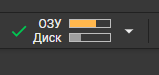

Для предотвращения переполнения ОЗУ может помочь библиотека `gc`. Вставьте строчку `gc.collect()` в цикл ваших экспериментов для сбора и удаления временных данных (кеш).

In [1]:
import os
import gc
import time
import random

import numpy as np
import matplotlib.pyplot as plt
import gdown

from PIL import Image
from tensorflow.keras.preprocessing import image

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization, concatenate
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K


In [2]:
# Скачиваем архив
DATA_URL = 'https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip'
ARCHIVE_NAME = 'construction_256x192.zip'

gdown.download(DATA_URL, ARCHIVE_NAME, quiet=False)

# Распаковка архива
!unzip -q -o 'construction_256x192.zip'

print('Датасет загружен и распакован')


Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip
To: /content/construction_256x192.zip
100%|██████████| 214M/214M [00:09<00:00, 21.7MB/s]


Датасет загружен и распакован


In [3]:
# Размеры изображений
IMG_WIDTH = 192
IMG_HEIGHT = 256

TRAIN_DIRECTORY = 'train'
VAL_DIRECTORY = 'val'

def load_folder_images(base_dir, subfolder):
    folder_path = os.path.join(base_dir, subfolder)
    loaded = []

    start = time.time()
    for file_name in sorted(os.listdir(folder_path)):
        img_path = os.path.join(folder_path, file_name)
        loaded.append(image.load_img(img_path, target_size=(IMG_WIDTH, IMG_HEIGHT)))

    print(f'{base_dir}/{subfolder}: загружено {len(loaded)} файлов за {round(time.time() - start, 2)} c')
    return loaded

train_images = load_folder_images(TRAIN_DIRECTORY, 'original')
val_images = load_folder_images(VAL_DIRECTORY, 'original')

train_segments = load_folder_images(TRAIN_DIRECTORY, 'segment')
val_segments = load_folder_images(VAL_DIRECTORY, 'segment')


train/original: загружено 1900 файлов за 0.3 c
val/original: загружено 100 файлов за 0.02 c
train/segment: загружено 1900 файлов за 0.26 c
val/segment: загружено 100 файлов за 0.01 c


In [4]:
# 16 классов датасета
FLOOR = (100, 100, 100)
CEILING = (0, 0, 100)
WALL = (0, 100, 0)
COLUMN = (100, 0, 0)
APERTURE = (0, 100, 100)
DOOR = (100, 0, 100)
WINDOW = (100, 100, 0)
EXTERNAL = (200, 200, 200)
RAILINGS = (0, 200, 0)
BATTERY = (200, 0, 0)
PEOPLE = (0, 200, 200)
LADDER = (0, 0, 200)
INVENTORY = (200, 0, 200)
LAMP = (200, 200, 0)
WIRE = (0, 100, 200)
BEAM = (100, 0, 200)

NUM_CLASSES = 7

CLASS_GROUPS = {
    0: [FLOOR],
    1: [CEILING],
    2: [WALL],
    3: [APERTURE, DOOR, WINDOW],
    4: [COLUMN, RAILINGS, LADDER],
    5: [INVENTORY],
    6: [LAMP, WIRE, BEAM, EXTERNAL, BATTERY, PEOPLE],
}

def masks_to_sparse_classes(mask_images):
    # Преобразуем цветные маски в карты классов 0...6
    converted_masks = []

    for mask_img in mask_images:
        rgb_mask = np.array(mask_img)
        class_mask = np.zeros((IMG_WIDTH, IMG_HEIGHT, 1), dtype='uint8')

        for class_id, colors in CLASS_GROUPS.items():
            for color in colors:
                pixels = np.all(rgb_mask == color, axis=-1)
                class_mask[pixels] = class_id

        converted_masks.append(class_mask)

    return np.asarray(converted_masks)

def images_to_float_array(img_list):
    # Оригинальные изображения переводятся в float и нормируются к диапазону 0...1
    return np.asarray([image.img_to_array(img) for img in img_list], dtype='float32') / 255.0

print('Подготовка изображений и масок начата')

x_train = images_to_float_array(train_images)
x_val = images_to_float_array(val_images)

y_train_sparse = masks_to_sparse_classes(train_segments)
y_val_sparse = masks_to_sparse_classes(val_segments)

print('Подготовка данных завершена')
print('x_train:', x_train.shape)
print('y_train_sparse:', y_train_sparse.shape)
print('x_val:', x_val.shape)
print('y_val_sparse:', y_val_sparse.shape)


Подготовка изображений и масок начата
Подготовка данных завершена
x_train: (1900, 192, 256, 3)
y_train_sparse: (1900, 192, 256, 1)
x_val: (100, 192, 256, 3)
y_val_sparse: (100, 192, 256, 1)


In [5]:
def conv_block(x, filters):
    x = Conv2D(filters, kernel_size=(3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(filters, kernel_size=(3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    return x

def decoder_step(x, skip_tensor, filters):
    x = Conv2DTranspose(filters, kernel_size=(2, 2), strides=(2, 2), padding='same')(x)
    x = concatenate([skip_tensor, x], axis=3)
    x = conv_block(x, filters)
    return x

def create_unet_model(input_shape, num_classes):
    # Энкодер сжимает изображение и накапливает признаки
    net_input = Input(shape=input_shape)

    enc_1 = conv_block(net_input, 32)
    down_1 = MaxPooling2D(pool_size=(2, 2))(enc_1)

    enc_2 = conv_block(down_1, 64)
    down_2 = MaxPooling2D(pool_size=(2, 2))(enc_2)

    # Центральный слой хранит наиболее сжатое представление изображения
    center = conv_block(down_2, 128)

    # Декодер восстанавливает размер маски и использует соединения
    dec_2 = decoder_step(center, enc_2, 64)
    dec_1 = decoder_step(dec_2, enc_1, 32)

    # На выходе для каждого пикселя выдаётся вероятность принадлежности к одному из 7 классов
    output_mask = Conv2D(num_classes, kernel_size=(1, 1), activation='softmax', padding='same')(dec_1)

    return Model(inputs=net_input, outputs=output_mask)

model = create_unet_model((IMG_WIDTH, IMG_HEIGHT, 3), NUM_CLASSES)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 192, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 192, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 192, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 192, 256,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 192, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 96, 128,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 96, 128,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 128,   │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 96, 128,   │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 128,   │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 48, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 48, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 64,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 48, 64,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 64,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 96, 128,   │     32,832 │ batch_normalizat… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96, 128,   │          0 │ batch_normalizat

 Total params: 469,287 (1.79 MB)

 Trainable params: 468,007 (1.79 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [6]:
gc.collect()

# Метка класса хранится одним числом для каждого пикселя
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS = 40
BATCH_SIZE = 16

print(f'Запуск обучения U-Net на {EPOCHS} эпохах.')
train_start = time.time()

history = model.fit(
    x_train,
    y_train_sparse,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val_sparse),
    verbose=1
)

train_minutes = round((time.time() - train_start) / 60, 2)
print(f'Обучение завершено за {train_minutes} минут.')


Запуск обучения U-Net на 40 эпохах
Epoch 1/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 71s 369ms/step - accuracy: 0.3046 - loss: 1.9265 - val_accuracy: 0.3947 - val_loss: 1.7556
Epoch 2/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 36s 164ms/step - accuracy: 0.5299 - loss: 1.5361 - val_accuracy: 0.2740 - val_loss: 1.8435
Epoch 3/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 20s 164ms/step - accuracy: 0.6166 - loss: 1.3254 - val_accuracy: 0.4777 - val_loss: 1.5768
Epoch 4/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 20s 167ms/step - accuracy: 0.6439 - loss: 1.2203 - val_accuracy: 0.4742 - val_loss: 1.6387
Epoch 5/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 20s 169ms/step - accuracy: 0.6584 - loss: 1.1504 - val_accuracy: 0.5415 - val_loss: 1.4125
Epoch 6/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 20s 170ms/step - accuracy: 0.6671 - loss: 1.1057 - val_accuracy: 0.5488 - val_loss: 1.3760
Epoch 7/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 21s 172ms/step - accuracy: 0.6779 - loss: 1.0527 - val_accuracy: 0.5568 - val_loss: 1.3543
Epoch 8/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 20s 169m

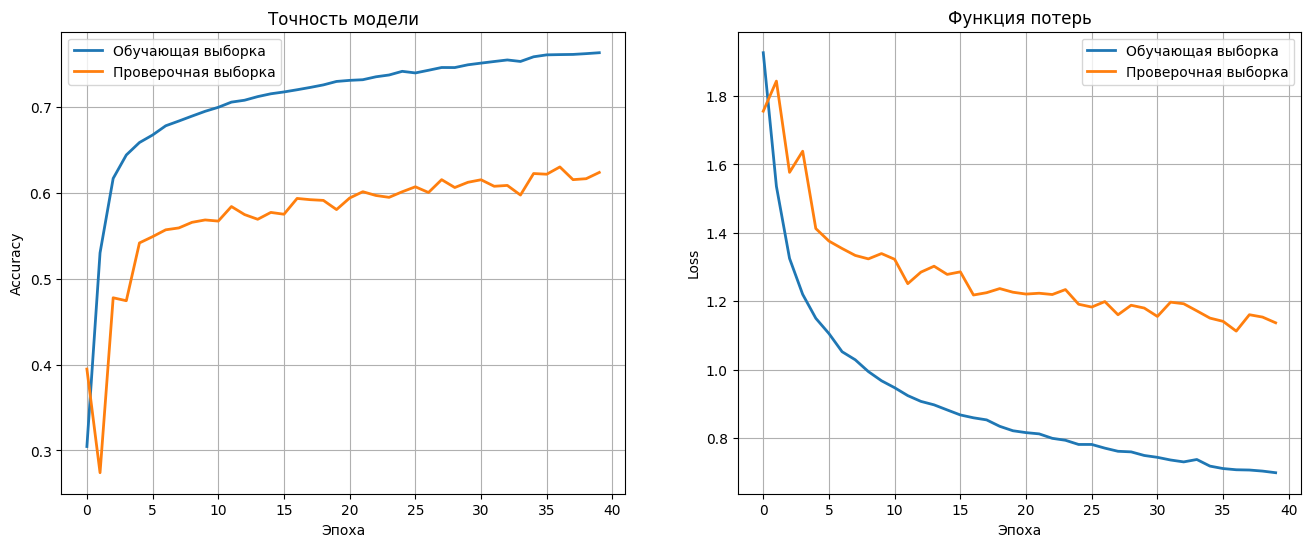

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


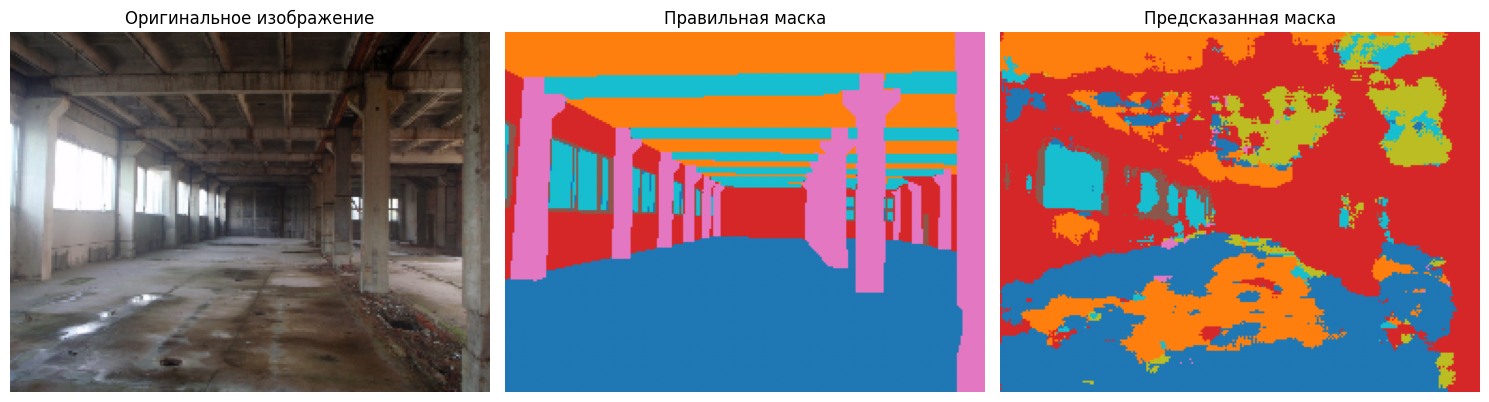

In [7]:
def show_training_curves(history):
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Обучающая выборка', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Проверочная выборка', linewidth=2)
    plt.title('Точность модели')
    plt.xlabel('Эпоха')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Обучающая выборка', linewidth=2)
    plt.plot(history.history['val_loss'], label='Проверочная выборка', linewidth=2)
    plt.title('Функция потерь')
    plt.xlabel('Эпоха')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.show()

def show_random_segmentation(model, images, true_masks):
    sample_index = random.randint(0, len(images) - 1)

    probabilities = model.predict(np.expand_dims(images[sample_index], axis=0))
    predicted_mask = np.argmax(probabilities[0], axis=-1)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(images[sample_index])
    plt.title('Оригинальное изображение')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(true_masks[sample_index].squeeze(), cmap='tab10')
    plt.title('Правильная маска')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(predicted_mask, cmap='tab10')
    plt.title('Предсказанная маска')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

show_training_curves(history)
show_random_segmentation(model, x_val, y_val_sparse)
